## Setup and Imports

In [40]:
# Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

# Visualization setup
%matplotlib inline

## Load the Dataset

In [ ]:
# Load the dataset
df = pd.read_csv('../data/v2/athens_fcd_output_10hour.csv', sep=';')

# Check the first few rows
df.head()

,timestep_time,vehicle_angle,vehicle_id,vehicle_lane,vehicle_pos,vehicle_slope,vehicle_speed,vehicle_type,vehicle_x,vehicle_y
0,0.0,173.49,veh0,449901015_0,5.10,0.0,0.00,DEFAULT_VEHTYPE,472.16,106.95
1,1.0,173.49,veh0,449901015_0,7.12,0.0,2.02,DEFAULT_VEHTYPE,472.39,104.94
2,2.0,173.49,veh0,449901015_0,10.97,0.0,3.85,DEFAULT_VEHTYPE,472.82,101.11
3,3.0,173.49,veh0,449901015_0,17.17,0.0,6.19,DEFAULT_VEHTYPE,473.53,94.96
4,4.0,173.96,veh0,449901015_0,25.88,0.0,8.71,DEFAULT_VEHTYPE,474.44,86.30


## Feature Engineering and Preprocessing

In [42]:
# Drop unnecessary columns
df = df.drop(columns=['vehicle_lane', 'vehicle_type'])

# Fill missing values if necessary (you can decide on a strategy)
df = df.fillna(method='ffill')

# Create a new feature: Remaining distance to the destination (assume final destination as last vehicle_x, vehicle_y)
# For this example, we assume the destination is the last point in the dataset for each vehicle.

# Get the last known positions of the vehicle as the destination
last_x = df.groupby('vehicle_id')['vehicle_x'].transform('last')
last_y = df.groupby('vehicle_id')['vehicle_y'].transform('last')

# Calculate the remaining distance to the destination at each timestep
df['remaining_distance'] = np.sqrt((last_x - df['vehicle_x'])**2 + (last_y - df['vehicle_y'])**2)

# Create a feature for elapsed time (time since start)
df['elapsed_time'] = df.groupby('vehicle_id')['timestep_time'].transform(lambda x: x - x.min())

# Check the modified dataframe
df.head()

C:\Users\george\AppData\Local\Temp\ipykernel_25988\883264149.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,timestep_time,vehicle_angle,vehicle_id,vehicle_pos,vehicle_slope,vehicle_speed,vehicle_x,vehicle_y,remaining_distance,elapsed_time
0,0.0,173.49,veh0,5.10,0.0,0.00,472.16,106.95,1866.690790,0.0
1,1.0,173.49,veh0,7.12,0.0,2.02,472.39,104.94,1867.265526,1.0
2,2.0,173.49,veh0,10.97,0.0,3.85,472.82,101.11,1868.373836,2.0
3,3.0,173.49,veh0,17.17,0.0,6.19,473.53,94.96,1870.150811,3.0
4,4.0,173.96,veh0,25.88,0.0,8.71,474.44,86.30,1872.767121,4.0


## Defining Target and Features

In [44]:
# Define the target (ETA = time remaining)
# For simplicity, assume the arrival time is the last timestep, and calculate time remaining at each step
last_time = df.groupby('vehicle_id')['timestep_time'].transform('last')
df['remaining_time'] = last_time - df['timestep_time']

# Define the features and target
features = ['vehicle_angle', 'vehicle_speed', 'vehicle_x', 'vehicle_y', 'vehicle_pos', 'remaining_distance', 'elapsed_time']
target = 'remaining_time'

# Check that everything is in order
df[features + [target]].head()

,vehicle_angle,vehicle_speed,vehicle_x,vehicle_y,vehicle_pos,remaining_distance,elapsed_time,remaining_time
0,173.49,0.00,472.16,106.95,5.10,1866.690790,0.0,313.0
1,173.49,2.02,472.39,104.94,7.12,1867.265526,1.0,312.0
2,173.49,3.85,472.82,101.11,10.97,1868.373836,2.0,311.0
3,173.49,6.19,473.53,94.96,17.17,1870.150811,3.0,310.0
4,173.96,8.71,474.44,86.30,25.88,1872.767121,4.0,309.0


## Train-Test Split

In [45]:
# Split the data into training and test sets
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the data
print("Training data shape: ", X_train.shape)
print("Test data shape: ", X_test.shape)

Training data shape:  (6706555, 7)
Test data shape:  (1676639, 7)


## Training the XGBoost Model

In [47]:
# Train the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.1, max_depth=10, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model using Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error on test set:", mae)

Mean Absolute Error on test set: 92.53276583714033


## Randomized Grid Search Cross Validation

In [48]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': np.arange(100, 501, 100),
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': np.arange(3, 11),
    'min_child_weight': np.arange(1, 11),
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgb_model,
                                   param_distributions=param_dist,
                                   n_iter=50,  # Number of random combinations to try
                                   scoring='neg_mean_absolute_error',
                                   cv=5,
                                   random_state=42,
                                   n_jobs=-1)  # Use all available cores

# Fit the model
random_search.fit(X_train, y_train)

# Get the best model and make predictions
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
print("Best Mean Absolute Error on test set:", mae)
print("Best Hyperparameters:", random_search.best_params_)

Best Mean Absolute Error on test set: 77.61857414113615
Best Hyperparameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 0.8}


## Using the Model for Live Predictions

In [49]:
# Save the trained model to a file for later use
xgb_model.save_model('xgboost_eta_model.json')

In [50]:
# Load the model for making predictions
loaded_model = xgb.XGBRegressor()
loaded_model.load_model('xgboost_eta_model.json')

# Use live data for prediction (dummy data here)
live_data = {
    'vehicle_angle': [45],
    'vehicle_speed': [20],
    'vehicle_x': [150],
    'vehicle_y': [75],
    'vehicle_pos': [0.5],
    'remaining_distance': [10],
    'elapsed_time': [15]
}

live_df = pd.DataFrame(live_data)
eta_prediction = loaded_model.predict(live_df)
print("Predicted ETA:", eta_prediction[0])

Predicted ETA: 68.22052


In [51]:
print(df['remaining_time'].describe())

count    8.383194e+06
mean     2.791528e+02
std      2.976276e+02
min      0.000000e+00
25%      9.000000e+01
50%      1.970000e+02
75%      3.610000e+02
max      3.715000e+03
Name: remaining_time, dtype: float64


In [52]:
print(df['remaining_time'].unique())

[ 313.  312.  311. ... 3451. 3450. 3449.]


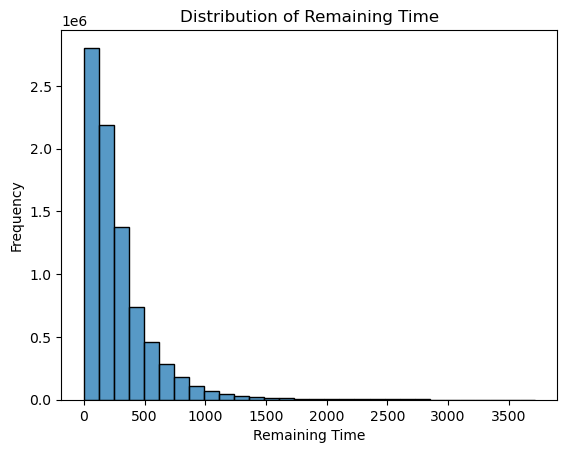

In [53]:
sns.histplot(df['remaining_time'], bins=30)
plt.title('Distribution of Remaining Time')
plt.xlabel('Remaining Time')
plt.ylabel('Frequency')
plt.show()